# Class 6 — FDE Data Validation with FlashEats

Yesterday, you proved you could **retrieve** data from multiple systems.

Today the question is different:

> **Can we safely use that data to make a business decision?**

This is not a generic data-cleaning lab.

## FDE validation mindset

**Business claim → assumptions → validation contract → targeted checks → stakeholder clarification → PASS / WARN / FAIL → publish decision**

### Concepts

**1. Validation is decision-dependent**  
A field can be good enough for weekly reporting but unsafe for a live operational decision.

**2. Turn assumptions into contracts**  
Business assumption → data expectation → executable check → action.

**3. Separate three validation types**
- Technical: chronology, IDs, categories, mappings
- Semantic: what does a status or ETA actually mean?
- Organizational: who owns the KPI definition?

**4. Never silently fix ambiguity**  
Do not encode thresholds or category mappings without ownership.

**5. Output a validation gate**  
The deliverable is not merely a cleaned dataframe. It is a decision:
PASS / WARN / FAIL / UNKNOWN.

In [1]:
!pip -q install pandas matplotlib

import json
import sqlite3
import zipfile
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

# ------------------------------------------------------------
# Robust pack discovery for Colab / local runs
# ------------------------------------------------------------

def find_pack_root(search_root=Path("/content")):
    candidates = list(search_root.rglob("FlashEats_Classroom_Pack_V2"))
    for candidate in candidates:
        db = candidate / "database" / "flasheats.db"
        if db.exists():
            return candidate
    return None

# Local run: the notebook usually already lives inside the pack root.
BASE = None
if (Path.cwd() / "database" / "flasheats.db").exists():
    BASE = Path.cwd()
elif Path.cwd().name == "FlashEats_Classroom_Pack_V2":
    BASE = Path.cwd()

if BASE is None:
    BASE = find_pack_root()

if BASE is None:
    try:
        from google.colab import files

        print("Upload: FlashEats_Class6_Classroom_Pack.zip")
        uploaded = files.upload()

        zip_name = next(name for name in uploaded if name.endswith(".zip"))

        extract_dir = Path("/content/flasheats_class6")
        extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall(extract_dir)

        BASE = find_pack_root(Path("/content"))

    except Exception as e:
        print("Automatic Colab setup failed:", e)

# Local fallback: search current working directory too
if BASE is None:
    BASE = find_pack_root(Path.cwd())

print("Detected BASE:", BASE)

if BASE is None:
    raise FileNotFoundError(
        "Could not find FlashEats_Classroom_Pack_V2. "
        "Upload/extract the classroom pack ZIP, then rerun this cell."
    )

DB_PATH = BASE / "database" / "flasheats.db"

print("Database path:", DB_PATH)
print("Database exists:", DB_PATH.exists())

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found at {DB_PATH}")

zsh:1: command not found: pip


Detected BASE: /Users/parthdagia/flasheats-classroom-pack/divvyRebalancingWithMyIQ/flasheats-challenges
Database path: /Users/parthdagia/flasheats-classroom-pack/divvyRebalancingWithMyIQ/flasheats-challenges/database/flasheats.db
Database exists: True


## Load the updated FlashEats data

In [2]:
con = sqlite3.connect(BASE / "database" / "flasheats.db")

orders = pd.read_sql("SELECT * FROM orders", con)
restaurants = pd.read_sql("SELECT * FROM restaurants", con)
drivers = pd.read_sql("SELECT * FROM drivers", con)

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")

with open(BASE / "data" / "client_metric_definitions.json", "r") as f:
    metric_notes = json.load(f)

print("orders:", orders.shape)
print("tickets:", tickets.shape)
print("restaurant_status:", restaurant_status.shape)

display(orders.head())
display(tickets.head())
display(restaurant_status.head())
print(json.dumps(metric_notes, indent=2))

orders: (1603, 13)
tickets: (202, 5)
restaurant_status: (502, 4)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


,order_id,restaurant_id,status,last_updated_at
0,O00676,R040,READY,2026-08-17T13:29:00
1,O01506,R055,Ready,2026-08-27T16:37:00
2,O01484,R032,ready,2026-08-08T19:44:00
3,O00675,R012,handoff,2026-08-22T21:42:00
4,O00078,R027,unknown,2026-08-25T19:35:00


{
  "metric_under_review": "Late Delivery Rate",
  "leadership_claim": "Late Delivery Rate is 56%",
  "stakeholders": {
    "VP Operations": "Any delivered order after the promised ETA is late.",
    "Support Lead": "Only more than 10 minutes beyond ETA should count as meaningfully late.",
    "Finance": "Cancelled/refunded orders should not count in operational performance.",
    "Data Team": "Historical dashboard uses delivered orders with non-null actual delivery time."
  },
  "note": "No canonical KPI owner is formally documented."
}


# Challenge 1 — Can we defend the “56% late” claim?


Leadership says:

> **“Late Delivery Rate is 56%.”**

Before calculating anything, create a validation contract.

| Business assumption | Data expectation | How will you test it? | Severity if false |
|---|---|---|---|
| One row = one business order |  |  |  |
| Delivered orders have completion time |  |  |  |
| Promised ETA is valid |  |  |  |
| Event chronology is valid |  |  |  |
| “Late” has an agreed definition |  |  |  |

**Hint:** Don't start by cleaning. Ask: *what could make 56% misleading?*

In [3]:
print("Rows:", len(orders))
print("Unique orders:", orders["order_id"].nunique())
print(orders["final_status"].value_counts(dropna=False))

o = orders.copy()
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    o[c] = pd.to_datetime(o[c], format="mixed", errors="coerce")
o["status_norm"] = o["final_status"].str.strip().str.lower()
dedup = o.drop_duplicates("order_id", keep="first")
delivered = dedup[dedup["status_norm"] == "delivered"]

# How was "56%" produced? Try the plausible recipes.
def any_late(df):
    d = df.dropna(subset=["actual_delivery_at"])
    return (d["actual_delivery_at"] > d["promised_eta"]).mean()

print("\nReproducing the leadership number:")
print(f"  any delay > 0, delivered + non-null, deduplicated : {any_late(delivered):.1%}")
print(f"  same, on raw rows incl. duplicates                 : {any_late(o[o['status_norm'] == 'delivered']):.1%}")
print(f"  same, only exact 'delivered' (casing not fixed)    : {any_late(dedup[dedup['final_status'] == 'delivered']):.1%}")

# Executable validation contract
conflicting_dupes = (o[o["order_id"].duplicated(keep=False)]
                     .groupby("order_id").nunique().gt(1).any(axis=1).sum())
contract = pd.DataFrame([
    ("One row = one business order", "order_id unique",
     "rows vs unique order_id", len(o) - o["order_id"].nunique(), "HIGH",
     f"{len(o) - o['order_id'].nunique()} duplicate rows; {conflicting_dupes} of them conflict (traffic_bucket)"),
    ("Delivered orders have completion time", "actual_delivery_at not null when delivered",
     "null check on delivered", delivered["actual_delivery_at"].isna().sum(), "HIGH",
     "these silently leave the denominator"),
    ("Promised ETA is valid", "promised_eta >= created_at",
     "compare timestamps", (dedup["promised_eta"] < dedup["created_at"]).sum(), "MEDIUM",
     "ETA 10 min before the order existed"),
    ("Event chronology is valid", "created <= pickup <= delivery",
     "compare timestamps",
     ((dedup["pickup_at"] < dedup["created_at"]) | (dedup["actual_delivery_at"] < dedup["pickup_at"])).sum(), "MEDIUM",
     "delivered 5 min before pickup"),
    ("'Late' has an agreed definition", "one owner, one written rule",
     "read client_metric_definitions.json", len(metric_notes["stakeholders"]), "CRITICAL",
     metric_notes["note"]),
], columns=["business_assumption", "data_expectation", "test", "violations", "severity_if_false", "evidence"])
display(contract)

Rows: 1603
Unique orders: 1600
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64

Reproducing the leadership number:
  any delay > 0, delivered + non-null, deduplicated : 56.4%
  same, on raw rows incl. duplicates                 : 56.3%
  same, only exact 'delivered' (casing not fixed)    : 56.4%


,business_assumption,data_expectation,test,violations,severity_if_false,evidence
0,One row = one business order,order_id unique,rows vs unique order_id,3,HIGH,3 duplicate rows; 3 of them conflict (traffic_bucket)
1,Delivered orders have completion time,actual_delivery_at not null when delivered,null check on delivered,37,HIGH,these silently leave the denominator
2,Promised ETA is valid,promised_eta >= created_at,compare timestamps,4,MEDIUM,ETA 10 min before the order existed
3,Event chronology is valid,created <= pickup <= delivery,compare timestamps,5,MEDIUM,delivered 5 min before pickup
4,'Late' has an agreed definition,"one owner, one written rule",read client_metric_definitions.json,4,CRITICAL,No canonical KPI owner is formally documented.


### Challenge 1 answer

**Validation contract**

| Business assumption | Data expectation | How we test it | Result | Severity if false |
|:-|:-|:-|:-|:-|
| One row = one business order | `order_id` unique | rows vs unique ids | **FAIL**: 3 duplicates, and they conflict on `traffic_bucket` | HIGH |
| Delivered orders have completion time | `actual_delivery_at` not null | null check | **FAIL**: 37 delivered orders have none | HIGH |
| Promised ETA is valid | `promised_eta >= created_at` | timestamp compare | **FAIL**: 4 orders promised before they existed | MEDIUM |
| Event chronology is valid | created ≤ pickup ≤ delivery | timestamp compare | **FAIL**: 5 delivered before pickup | MEDIUM |
| "Late" has an agreed definition | One owner, one written rule | read the definitions file | **FAIL**: 4 stakeholders, 4 rules, no owner | CRITICAL |

**Can we defend "56% late"?** The *arithmetic* is defensible: 56.4% is exactly "any delay above 0 min, on delivered orders with a timestamp", and it barely moves with the data defects (56.3% with duplicates, 56.4% with casing unfixed). The *claim* is not defensible, because it silently picks one of four competing definitions, the strictest one, and nobody owns that choice. The duplicates, missing timestamps and bad ETAs are real but small; the **definition** is what could make 56% misleading.

# Challenge 2 — Stakeholders disagree on “late”


Read `client_metric_definitions.json`.

Calculate the metric under at least three definitions:
- any delay > 0 minutes,
- delay > 10 minutes,
- historical-style delivered/non-null population.

| Definition | Late rate | Business meaning |
|---|---:|---|

Then answer:

> **Which one should leadership publish, and who must own that decision?**

,stakeholder,definition,late,denominator,late_rate,business_meaning
0,VP Operations,"any delay > 0 min, delivered orders",843,1495,56.4%,Did we keep the exact promise? Counts a 1-minute miss as a failure
1,Support Lead,"delay > 10 min, delivered orders",349,1495,23.3%,Lateness a customer notices and complains about
2,Finance,"any delay > 0 min, cancelled excluded (same population as Ops)",843,1495,56.4%,Operational performance only; cancellations are a separate cost
3,Data Team (historical dashboard),"any delay > 0 min, delivered + non-null time",843,1495,56.4%,Reproduces the old dashboard: this is where 56% comes from
4,(what if) all orders as denominator,any delay > 0 min / every order incl. cancelled,843,1600,52.7%,What Finance warns against: cancellations dilute the rate
5,(what if) missing time counted as late,"delay > 10 min, null delivery time = late",386,1532,25.2%,Pessimistic upper bound for the Support definition


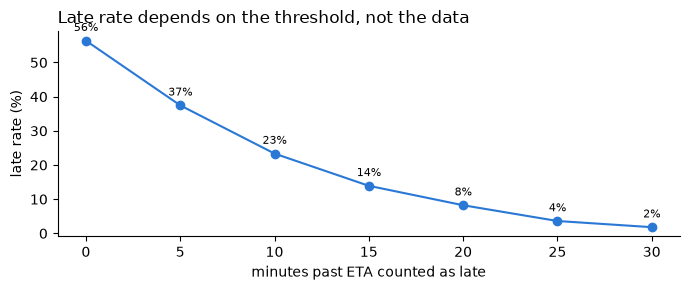

In [4]:
analysis = orders.drop_duplicates("order_id", keep="first").copy()

for c in ["promised_eta", "actual_delivery_at"]:
    analysis[c] = pd.to_datetime(analysis[c], format="mixed", errors="coerce")

analysis["delay_min"] = (
    analysis["actual_delivery_at"] - analysis["promised_eta"]
).dt.total_seconds() / 60

analysis["status_norm"] = analysis["final_status"].str.strip().str.lower()
deliv = analysis[analysis["status_norm"] == "delivered"]
deliv_ts = deliv.dropna(subset=["actual_delivery_at"])

def row(owner, rule, late, denom, meaning):
    return {"stakeholder": owner, "definition": rule, "late": int(late), "denominator": int(denom),
            "late_rate": f"{late / denom:.1%}", "business_meaning": meaning}

defs = pd.DataFrame([
    row("VP Operations", "any delay > 0 min, delivered orders",
        (deliv_ts["delay_min"] > 0).sum(), len(deliv_ts),
        "Did we keep the exact promise? Counts a 1-minute miss as a failure"),
    row("Support Lead", "delay > 10 min, delivered orders",
        (deliv_ts["delay_min"] > 10).sum(), len(deliv_ts),
        "Lateness a customer notices and complains about"),
    row("Finance", "any delay > 0 min, cancelled excluded (same population as Ops)",
        (deliv_ts["delay_min"] > 0).sum(), len(deliv_ts),
        "Operational performance only; cancellations are a separate cost"),
    row("Data Team (historical dashboard)", "any delay > 0 min, delivered + non-null time",
        (deliv_ts["delay_min"] > 0).sum(), len(deliv_ts),
        "Reproduces the old dashboard: this is where 56% comes from"),
    row("(what if) all orders as denominator", "any delay > 0 min / every order incl. cancelled",
        (deliv_ts["delay_min"] > 0).sum(), len(analysis),
        "What Finance warns against: cancellations dilute the rate"),
    row("(what if) missing time counted as late", "delay > 10 min, null delivery time = late",
        (deliv_ts["delay_min"] > 10).sum() + deliv["actual_delivery_at"].isna().sum(), len(deliv),
        "Pessimistic upper bound for the Support definition"),
])
display(defs)

# How sensitive is the rate to the threshold? This is the decision leadership is really making.
curve = pd.DataFrame({"threshold_min": range(0, 31, 5)})
curve["late_rate"] = [(deliv_ts["delay_min"] > t).mean() for t in curve["threshold_min"]]
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(curve["threshold_min"], curve["late_rate"] * 100, marker="o", color="#2a78d6")
for t, r in zip(curve["threshold_min"], curve["late_rate"]):
    ax.annotate(f"{r:.0%}", (t, r * 100), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
ax.set(title="Late rate depends on the threshold, not the data", xlabel="minutes past ETA counted as late",
       ylabel="late rate (%)")
ax.title.set_ha("left"); ax.title.set_position((0, 1))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Challenge 2 answer

| Definition | Late rate | Business meaning |
|:-|-:|:-|
| Any delay > 0 min (VP Ops, Data Team, Finance population) | **56.4%** | Missed the exact promise, even by 1 minute |
| Delay > 10 min (Support Lead) | **23.3%** | Late enough that customers notice and complain |
| Any delay, all orders incl. cancelled | 52.7% | The dilution Finance warns against |
| Delay > 10 min, missing time counted as late | 25.2% | Worst case for the Support definition |

Three of the four stakeholders actually agree on the *population* (delivered orders with a time); **the real disagreement is the threshold**, and the rate falls from 56% to 23% between 0 and 10 minutes.

**Which one should leadership publish?** Our recommendation: publish **"Late > 10 min = 23.3%"** as the headline KPI, because it matches what customers experience (Class 5: tickets cluster on genuinely late orders), and report **"on time to the minute = 43.6%"** next to it as the promise-accuracy metric. The 56% figure measures ETA precision, not customer harm.

**Who must own the decision?** The **VP Operations**: they run delivery and are accountable for the KPI. Support and Finance are *consulted* (customer impact, cancellation rule), and the Data Team *implements* it. Until that owner signs a written definition, **no** late-rate number should be published as "the" KPI. This is an organizational decision, not a data decision, so we must not make it for them in code.

# Challenge 3 — Validate categories without cleaning by instinct


Inspect:
- `final_status`
- `traffic_bucket`
- restaurant `status`
- support-ticket `category`

For each:
1. list observed values,
2. identify representation differences,
3. decide what is safe to normalize,
4. identify what requires owner confirmation.

Remember:

> `"Delivered"` vs `"delivered"` is likely representation.  
> `"handoff"` vs `"handed_off"` may be semantics.

In [5]:
for col in ["final_status", "traffic_bucket"]:
    print("\n", col)
    print(orders[col].value_counts(dropna=False))

print("\nRestaurant status")
print(restaurant_status["status"].value_counts(dropna=False))

print("\nSupport category")
print(tickets["category"].value_counts(dropna=False))


 final_status
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64

 traffic_bucket
traffic_bucket
medium    635
high      448
low       381
severe    136
HIGH        3
Name: count, dtype: int64

Restaurant status
status
preparing     171
handed_off    168
ready         157
ready           2
READY           1
Ready           1
handoff         1
unknown         1
Name: count, dtype: int64

Support category
category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64


# Challenge 4 — Cross-source integrity


Validate mappings:
- `orders.restaurant_id` → restaurants
- `orders.driver_id` → drivers
- `tickets.order_id` → orders
- `restaurant_status.order_id` → orders

Produce:

| Relationship | Coverage % | Status | Risk |
|---|---:|---|---|

Then discuss:

> If 1% is unmapped, is that acceptable?

It depends on which business decision uses those records.

In [6]:
# Example:
# orders["restaurant_id"].dropna().isin(restaurants["restaurant_id"]).mean()

# TODO: calculate mapping coverage for all relationships.

# Challenge 5 — Freshness is an SLA question


Use `restaurant_status.csv`.

Determine whether status updates are fresh enough for:
- weekly analytics,
- live customer ETA,
- restaurant accountability.

The same record may be acceptable for one use case and unsafe for another.

**Hint:** join status records to order lifecycle timestamps and inspect timing.

In [7]:
# TODO:
# Merge restaurant_status with orders on order_id
# Parse timestamps
# Compare last_updated_at with order lifecycle timestamps

# Challenge 6 — Build the validation gate


Summarize the investigation:

| Check | Status | Evidence | Action |
|---|---|---|---|
| Business grain |  |  |  |
| Timestamp chronology |  |  |  |
| KPI definition |  |  |  |
| Category semantics |  |  |  |
| Cross-source mapping |  |  |  |
| Freshness |  |  |  |

Use only:
**PASS / WARN / FAIL / UNKNOWN**

Finally answer:

> **Should leadership publish “Late Delivery Rate = 56%” today?**

What exactly must happen before the metric becomes publishable?

In [8]:
validation_report = {
    "business_grain": None,
    "timestamp_chronology": None,
    "kpi_definition": None,
    "category_semantics": None,
    "cross_source_mapping": None,
    "freshness": None,
    "publish_56_percent": None
}
print(validation_report)

{'business_grain': None, 'timestamp_chronology': None, 'kpi_definition': None, 'category_semantics': None, 'cross_source_mapping': None, 'freshness': None, 'publish_56_percent': None}


# Final takeaway

The job was not to make the data look clean.

The job was to decide:

> **Is this data safe enough for this decision, and what remains unresolved?**